In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, random_split

In [13]:
dataset_path="./data/animal-image-datasetdog-cat-and-panda/animals/animals"
classes=["cats","dogs","panda"]
image_paths=[]
labels=[]
for classname in classes:
	class_path=os.path.join(dataset_path,classname)
	for filename in os.listdir(class_path):
		image_paths.append(os.path.join(class_path,filename))
		labels.append(classname)
	
print("Total images:",len(image_paths))
print("Labels:", len(labels))
from collections import Counter
print(Counter(labels))

Total images: 3000
Labels: 3000
Counter({'cats': 1000, 'dogs': 1000, 'panda': 1000})


In [14]:
transform=transforms.Compose([
	transforms.Resize((224,224)),
	transforms.ToTensor(),
	transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [15]:
dataset=datasets.ImageFolder(dataset_path,transform=transform)
print("Number of images:", len(dataset))
print("Classes:", dataset.classes)
print("Class mapping:", dataset.class_to_idx)


Number of images: 3000
Classes: ['cats', 'dogs', 'panda']
Class mapping: {'cats': 0, 'dogs': 1, 'panda': 2}


In [16]:
train_size=int(0.7*len(dataset))
val_size=int(0.15*len(dataset))
test_size=len(dataset)-train_size-val_size
train_dataset,val_dataset,test_dataset=random_split(dataset,[train_size,val_size,test_size],generator=torch.Generator().manual_seed(42))
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 2100
Validation: 450
Test: 450


In [17]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=32,shuffle=False)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([0, 1, 2, 0, 1, 2, 1, 1, 1, 0, 1, 2, 2, 0, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1,
        0, 2, 2, 1, 0, 1, 2, 2])


In [18]:
model=models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model.parameters():
    param.requires_grad = False

In [19]:
model.fc=nn.Sequential(
    nn.Linear(512,256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256,3)
)

In [20]:
print(model.fc)
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=3, bias=True)
)
fc.0.weight
fc.0.bias
fc.3.weight
fc.3.bias


In [21]:
optimizer=optim.Adam(model.fc.parameters(),lr=0.001)

Criterion=nn.CrossEntropyLoss()

In [22]:
num_epochs = 10
best_val_accuracy = 0.0
for epoch in range(num_epochs):
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        optimizer.zero_grad()
        
        outputs = model(images)
        
        loss = Criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_accuracy = train_correct / train_total


    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            outputs = model(images)

            loss = Criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_accuracy = val_correct / val_total

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "best_resnet18.pth"
        )

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch [1/10] Train Loss: 0.2505 Train Acc: 0.9005 Val Loss: 0.0667 Val Acc: 0.9689
Epoch [2/10] Train Loss: 0.0959 Train Acc: 0.9657 Val Loss: 0.0559 Val Acc: 0.9800
Epoch [3/10] Train Loss: 0.0991 Train Acc: 0.9614 Val Loss: 0.0615 Val Acc: 0.9800
Epoch [4/10] Train Loss: 0.0903 Train Acc: 0.9700 Val Loss: 0.0546 Val Acc: 0.9822
Epoch [5/10] Train Loss: 0.0814 Train Acc: 0.9705 Val Loss: 0.0562 Val Acc: 0.9800
Epoch [6/10] Train Loss: 0.0644 Train Acc: 0.9767 Val Loss: 0.0500 Val Acc: 0.9733
Epoch [7/10] Train Loss: 0.0634 Train Acc: 0.9771 Val Loss: 0.0579 Val Acc: 0.9756
Epoch [8/10] Train Loss: 0.0737 Train Acc: 0.9733 Val Loss: 0.0475 Val Acc: 0.9822
Epoch [9/10] Train Loss: 0.0499 Train Acc: 0.9824 Val Loss: 0.0468 Val Acc: 0.9733
Epoch [10/10] Train Loss: 0.0625 Train Acc: 0.9752 Val Loss: 0.0529 Val Acc: 0.9800


In [24]:
model.load_state_dict(
    torch.load("best_resnet18.pth")
)

<All keys matched successfully>

In [25]:
model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        loss = Criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        test_correct += (predictions == labels).sum().item()
        test_total += labels.size(0)

test_loss /= test_total
test_accuracy = test_correct / test_total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.0335
Test Accuracy: 0.9867


In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)

print(cm)

[[140   2   0]
 [  3 163   0]
 [  1   0 141]]


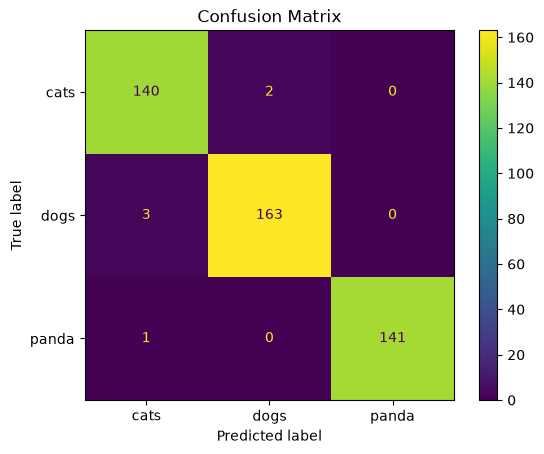

In [27]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dataset.classes
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

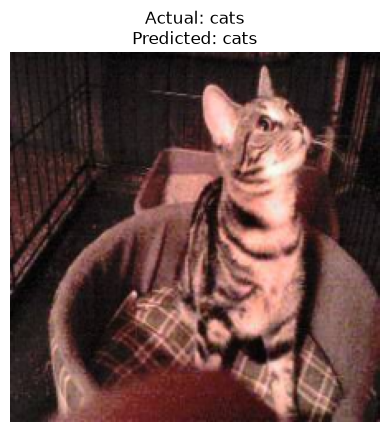

Actual: cats, Predicted: cats


In [32]:
model.eval()

image, label = test_dataset[332]

with torch.no_grad():
    output = model(image.unsqueeze(0))
    _, predicted = torch.max(output, 1)

class_names = dataset.classes


mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

display_image = image * std + mean

display_image = display_image.permute(1, 2, 0)

display_image = display_image.clamp(0, 1)

plt.imshow(display_image)

plt.title(
    f"Actual: {class_names[label]}\n"
    f"Predicted: {class_names[predicted.item()]}"
)
plt.axis("off")
plt.show()

print(
    f"Actual: {class_names[label]}, "
    f"Predicted: {class_names[predicted.item()]}"
)